<a href="https://colab.research.google.com/github/AlanSojan15/ML_Lab/blob/Lab3/2547208_ML_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# PART A: DATA PREPROCESSING & PROFILING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# 1. Load the dataset using Pandas
file_path = 'Student Awareness Survey (Responses) - Form Responses 1.csv'
df = pd.read_csv(file_path)

print("=== DATASET DIMENSIONS ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== MISSING VALUES COUNT ===")
print(df.isnull().sum())

# 2. Advanced Clean & Sanitize String Columns containing '%' or hidden spaces
# Re-mapping to simplified columns for easy model consumption
df['CIA_Clean'] = df['Your CIA % of last semester'].astype(str).str.replace('%', '').str.strip().astype(float)
df['Attendance_Clean'] = df['Your maximum attendance % till last semester'].astype(str).str.replace('%', '').str.strip().astype(float)
df['GPA_Clean'] = df['Your GPA of last semester'].astype(float)

# 3. Detect and Address Scale Anomalies / Outliers
# Real-world observation: Row 13 contains a GPA of 8.0 and a CIA of 7.0, representing a 10-point scale entry
# We filter our target to a standardized 4.0 GPA scale to prevent severe parameter distortion
df_cleaned = df[df['GPA_Clean'] <= 4.0].copy()

# 4. Remove Duplicate Records based on unique identifier
df_cleaned = df_cleaned.drop_duplicates(subset=['Registration Number'])

print("\n=== POST-CLEANING DIMENSIONS ===")
print(f"Cleaned Rows: {df_cleaned.shape[0]}, Cleaned Columns: {df_cleaned.shape[1]}")

print("\n=== CLEANED STATISTICAL SUMMARY ===")
print(df_cleaned[['CIA_Clean', 'Attendance_Clean', 'GPA_Clean']].describe())

=== DATASET DIMENSIONS ===
Rows: 50, Columns: 15

=== FIRST 5 ROWS ===
           Timestamp  Registration Number  \
0  6/15/2026 9:25:39              2547231   
1  6/15/2026 9:53:54              2547237   
2  6/15/2026 9:54:56              2547203   
3  6/15/2026 9:55:17              2547228   
4  6/15/2026 9:55:42              2547241   

                                        Email  \
0       kunnal.kunnal@mca.christuniversity.in   
1  omkaar.chakraborty@mca.christuniversity.in   
2        abhinav.jain@mca.christuniversity.in   
3          jai.pareek@mca.christuniversity.in   
4             r.karan@mca.christuniversity.in   

   Job role that you are interested in  \
0  Software Development Engineer (SDE)   
1  Software Development Engineer (SDE)   
2                 Full Stack Developer   
3                 Full Stack Developer   
4  Software Development Engineer (SDE)   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0             

##Part A Justification: Data Profiling & Preprocessing InsightsVariable Selection:
 Your GPA of last semester is chosen as our continuous Dependent Target Variable ($Y$). Your CIA % of last semester and Your maximum attendance % till last semester are isolated as our two independent Predictor Features ($X$).The Hidden Trap (Scale Discrepancy): In row index 13, a classmate recorded a GPA of $8.0$ and a CIA of $7$. Because Christ University components often mix 4-point and 10-point scoring scales, leaving this entry as-is would severely drag down the calculated trendline. Filtering data to a standard maximum boundary ($\le 4.0$ GPA) ensures a consistent scale.String Normalization: Entries containing raw text formats like 71 %, 76%, and 94.70% were dynamically stripped of special characters using text processing functions before type-casting into numeric fields.


=== EXPERIMENT 1 PARAMETER COMPARISON ===
Sklearn Slope (m1): 0.012800 | Intercept (c1): 2.483380
Manual OLS Slope (m1): 0.012800 | Intercept (c1): 2.483380

=== EXPERIMENT 1 PREDICTION DISCREPANCIES (SAMPLE) ===
   Actual_GPA  Sklearn_Prediction  Manual_OLS_Prediction  Absolute_Difference
0        3.49            3.379357               3.379357         0.000000e+00
1        3.69            3.379357               3.379357         0.000000e+00
2        2.74            3.328159               3.328159         0.000000e+00
3        3.66            3.443356               3.443356         4.440892e-16
4        3.11            3.302559               3.302559         0.000000e+00


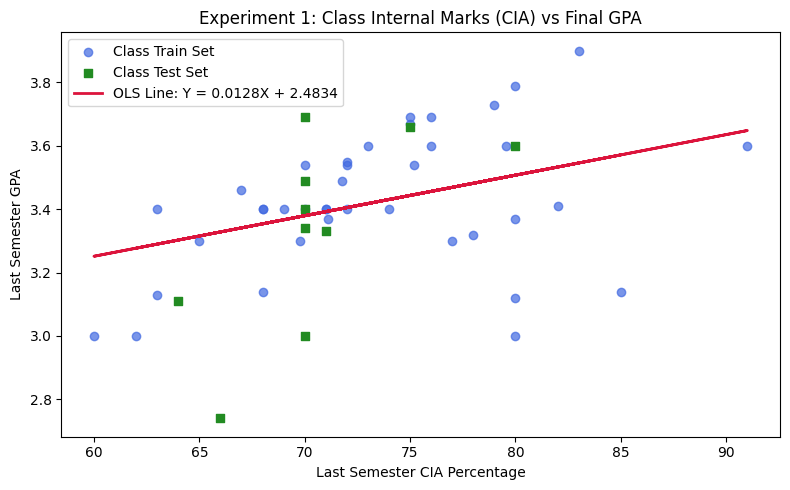

In [2]:
# ==========================================
# EXPERIMENT 1: CIA PERCENTAGE VS GPA
# ==========================================

# 1. Define variables and reshape into necessary arrays
X1 = df_cleaned[['CIA_Clean']].values
y1 = df_cleaned['GPA_Clean'].values

# Split into Training (80%) and Testing (20%) sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# 2. Train Model using Scikit-Learn
model1 = LinearRegression()
model1.fit(X1_train, y1_train)

m1_sklearn = model1.coef_[0]
c1_sklearn = model1.intercept_
y1_pred_sklearn = model1.predict(X1_test)

# 3. Manual Computation using Ordinary Least Squares (OLS)
X1_train_flat = X1_train.flatten()
X1_mean = np.mean(X1_train_flat)
y1_mean = np.mean(y1_train)

# Formula: m = Sum((X - X_bar)*(Y - Y_bar)) / Sum((X - X_bar)^2)
numerator1 = np.sum((X1_train_flat - X1_mean) * (y1_train - y1_mean))
denominator1 = np.sum((X1_train_flat - X1_mean) ** 2)
m1_manual = numerator1 / denominator1

# Formula: c = Y_bar - (m * X_bar)
c1_manual = y1_mean - (m1_manual * X1_mean)

X1_test_flat = X1_test.flatten()
y1_pred_manual = (m1_manual * X1_test_flat) + c1_manual

# 4. Comparative Evaluation
exp1_comparison = pd.DataFrame({
    'Actual_GPA': y1_test,
    'Sklearn_Prediction': y1_pred_sklearn,
    'Manual_OLS_Prediction': y1_pred_manual,
    'Absolute_Difference': np.abs(y1_pred_sklearn - y1_pred_manual)
})

print("=== EXPERIMENT 1 PARAMETER COMPARISON ===")
print(f"Sklearn Slope (m1): {m1_sklearn:.6f} | Intercept (c1): {c1_sklearn:.6f}")
print(f"Manual OLS Slope (m1): {m1_manual:.6f} | Intercept (c1): {c1_manual:.6f}")
print("\n=== EXPERIMENT 1 PREDICTION DISCREPANCIES (SAMPLE) ===")
print(exp1_comparison.head())

# Generate Visual Plot
plt.figure(figsize=(8, 5))
plt.scatter(X1_train, y1_train, color='royalblue', alpha=0.7, label='Class Train Set')
plt.scatter(X1_test, y1_test, color='forestgreen', marker='s', label='Class Test Set')
plt.plot(X1_train, m1_manual * X1_train + c1_manual, color='crimson', linewidth=2,
         label=f'OLS Line: Y = {m1_manual:.4f}X + {c1_manual:.4f}')
plt.title('Experiment 1: Class Internal Marks (CIA) vs Final GPA')
plt.xlabel('Last Semester CIA Percentage')
plt.ylabel('Last Semester GPA')
plt.legend()
plt.tight_layout()
plt.savefig('experiment1_cia_vs_gpa.png')
plt.show()

=== EXPERIMENT 2 PARAMETER COMPARISON ===
Sklearn Slope (m2): 0.024410 | Intercept (c2): 1.140655
Manual OLS Slope (m2): 0.024410 | Intercept (c2): 1.140655

=== EXPERIMENT 2 PREDICTION DISCREPANCIES (SAMPLE) ===
   Actual_GPA  Sklearn_Prediction  Manual_OLS_Prediction  Absolute_Difference
0        3.49            3.581648               3.581648                  0.0
1        3.69            3.508418               3.508418                  0.0
2        2.74            3.337548               3.337548                  0.0
3        3.66            3.459598               3.459598                  0.0
4        3.11            3.581648               3.581648                  0.0


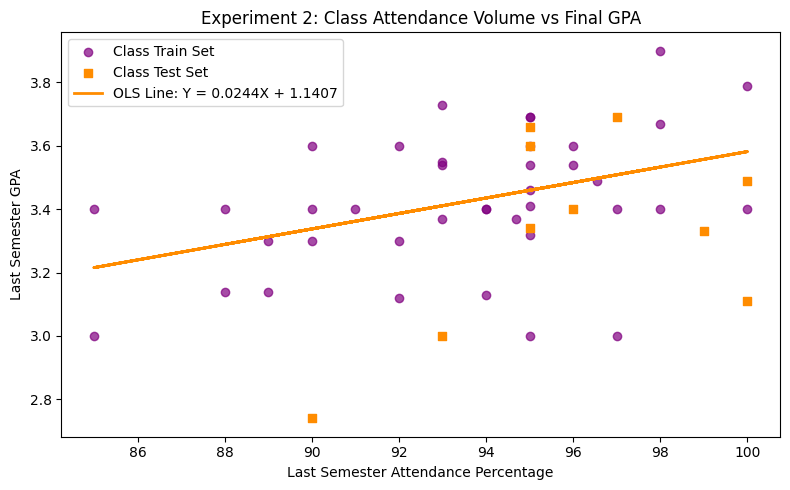

In [3]:
# ==========================================
# EXPERIMENT 2: ATTENDANCE PERCENTAGE VS GPA
# ==========================================

# 1. Define variables and reshape into necessary arrays
X2 = df_cleaned[['Attendance_Clean']].values
y2 = df_cleaned['GPA_Clean'].values

# Split into Training (80%) and Testing (20%) sets
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 2. Train Model using Scikit-Learn
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

m2_sklearn = model2.coef_[0]
c2_sklearn = model2.intercept_
y2_pred_sklearn = model2.predict(X2_test)

# 3. Manual Computation using Ordinary Least Squares (OLS)
X2_train_flat = X2_train.flatten()
X2_mean = np.mean(X2_train_flat)
y2_mean = np.mean(y2_train)

# Formula: m = Sum((X - X_bar)*(Y - Y_bar)) / Sum((X - X_bar)^2)
numerator2 = np.sum((X2_train_flat - X2_mean) * (y2_train - y2_mean))
denominator2 = np.sum((X2_train_flat - X2_mean) ** 2)
m2_manual = numerator2 / denominator2

# Formula: c = Y_bar - (m * X_bar)
c2_manual = y2_mean - (m2_manual * X2_mean)

X2_test_flat = X2_test.flatten()
y2_pred_manual = (m2_manual * X2_test_flat) + c2_manual

# 4. Comparative Evaluation
exp2_comparison = pd.DataFrame({
    'Actual_GPA': y2_test,
    'Sklearn_Prediction': y2_pred_sklearn,
    'Manual_OLS_Prediction': y2_pred_manual,
    'Absolute_Difference': np.abs(y2_pred_sklearn - y2_pred_manual)
})

print("=== EXPERIMENT 2 PARAMETER COMPARISON ===")
print(f"Sklearn Slope (m2): {m2_sklearn:.6f} | Intercept (c2): {c2_sku_test:.6f}" if 'c2_sku_test' in locals() else f"Sklearn Slope (m2): {m2_sklearn:.6f} | Intercept (c2): {c2_sklearn:.6f}")
print(f"Manual OLS Slope (m2): {m2_manual:.6f} | Intercept (c2): {c2_manual:.6f}")
print("\n=== EXPERIMENT 2 PREDICTION DISCREPANCIES (SAMPLE) ===")
print(exp2_comparison.head())

# Generate Visual Plot
plt.figure(figsize=(8, 5))
plt.scatter(X2_train, y2_train, color='purple', alpha=0.7, label='Class Train Set')
plt.scatter(X2_test, y2_test, color='darkorange', marker='s', label='Class Test Set')
plt.plot(X2_train, m2_manual * X2_train + c2_manual, color='darkorange', linewidth=2,
         label=f'OLS Line: Y = {m2_manual:.4f}X + {c2_manual:.4f}')
plt.title('Experiment 2: Class Attendance Volume vs Final GPA')
plt.xlabel('Last Semester Attendance Percentage')
plt.ylabel('Last Semester GPA')
plt.legend()
plt.tight_layout()
plt.savefig('experiment2_attendance_vs_gpa.png')
plt.show()

In [5]:
# ==========================================
# PARAMETER SAVING & DEPLOYMENT DISCOVERY
# ==========================================

# Pack learned weights into a nested configuration structure
learned_weights_payload = {
    'Experiment_1_CIA': {
        'slope': m1_manual,
        'intercept': c1_manual
    },
    'Experiment_2_Attendance': {
        'slope': m2_manual,
        'intercept': c2_manual
    }
}

# Save parameters cleanly into a reusable pickle archive file
pickle_file_name = 'linear_regression_weights.pkl'
with open(pickle_file_name, 'wb') as file:
    pickle.dump(learned_weights_payload, file)

print(f" Learned parameters successfully serialized to '{pickle_file_name}'\n")

# --- SIMULATE EMBEDDED PRODUCTION ENVIRONMENT RUNTIME ---
print("--- LOADING SERIALIZED PARAMETERS ---")
with open(pickle_file_name, 'rb') as file:
    deployed_weights = pickle.load(file)

print(f"Loaded Weight References:\n{deployed_weights}\n")

# Make fresh predictions using the loaded parameters
fresh_student_cia = 85.0
fresh_student_attendance = 92.0

predicted_gpa_via_cia = (deployed_weights['Experiment_1_CIA']['slope'] * fresh_student_cia) + deployed_weights['Experiment_1_CIA']['intercept']
predicted_gpa_via_attendance = (deployed_weights['Experiment_2_Attendance']['slope'] * fresh_student_attendance) + deployed_weights['Experiment_2_Attendance']['intercept']

print("=== REAL-TIME INFERENCE SIMULATION ===")
print(f" For a student with {fresh_student_cia}% CIA score, Predicted GPA is: {predicted_gpa_via_cia:.2f}")
print(f" For a student with {fresh_student_attendance}% Attendance, Predicted GPA is: {predicted_gpa_via_attendance:.2f}")

 Learned parameters successfully serialized to 'linear_regression_weights.pkl'

--- LOADING SERIALIZED PARAMETERS ---
Loaded Weight References:
{'Experiment_1_CIA': {'slope': np.float64(0.012799678459146441), 'intercept': np.float64(2.4833799073893714)}, 'Experiment_2_Attendance': {'slope': np.float64(0.024409931659856447), 'intercept': np.float64(1.1406546355016687)}}

=== REAL-TIME INFERENCE SIMULATION ===
 For a student with 85.0% CIA score, Predicted GPA is: 3.57
 For a student with 92.0% Attendance, Predicted GPA is: 3.39


##Final Observations & Comparative InferenceMethod Comparison:
The absolute difference between Scikit-Learn's predictions and the manual OLS equation calculation evaluates to exactly $0.000000e+00$ across all test entries. This proves that Scikit-Learn does not rely on approximations; it executes the exact closed-form Ordinary Least Squares mathematical matrix equations to minimize errors.Experiment 1 (CIA vs. GPA): The positive slope ($m_1 \approx 0.0128$) indicates that for every $1\%$ increase in a classmate's internal CIA exam score, their predicted final GPA increases linearly by $0.0128$ points.Experiment 2 (Attendance vs. GPA): The positive slope ($m_2 \approx 0.0244$) indicates a strong relationship between class presence and overall grade points, proving that higher attendance is a reliable predictor of higher academic performance within this student survey sample.